In [1]:
from PIL import Image
import os
import random
import numpy as np
import pandas as pd
import cv2
from collections import Counter

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import random
from collections import defaultdict
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.signal import find_peaks


import matplotlib.pyplot as plt

In [2]:
Debug = False

root = "photos"
exts = {".jpg"}
sizes, modes, formats, per_class = [], [], [], Counter()                                     
broken = []

for label in os.listdir(root):
    class_label = os.path.join(root, label)

    if not os.path.isdir(class_label):
        continue

    for file_name in os.listdir(class_label):
        ext = os.path.splitext(file_name)[1].lower()      

        if ext not in exts:
            continue         

        path = os.path.join(class_label, file_name)
        try:
            with Image.open(path) as img:
                img.load()
                sizes.append(img.size)
                modes.append(img.mode)        
                formats.append(img.format)
                per_class[label] += 1

                if(Debug): break                         
        except Exception as e:
            broken.append((path, str(e)))
        
        if(Debug): break

print("total:", sum(per_class.values()))
print("por classe:", per_class) # Quebrar linha
print("tamanhos únicos:", Counter(sizes).most_common(10))
print("modos:", Counter(modes))                                                              
print("formatos:", Counter(formats))                              
print("arquivos quebrados:", len(broken)) 

total: 6954
por classe: Counter({'257234_industrial_effect': 183, '237310_aberracao_cromatica': 183, '297611_canny_sketch': 183, '243360_edge_detection': 183, '260382_dithering_red_black_white': 183, '247145_border_detection': 183, '186629_canny_edge_detection': 183, '297611_radial_vignette': 183, '246955_fish_eye': 183, '175807_futuro': 183, '260382_difference_of_gaussians_flow_less': 183, '241163_edge_detection': 183, '186629_color_splash': 183, '260382_difference_of_gaussians_flow': 183, '260382_dithering_black_white': 183, '246955_color_mapping': 183, '257234_gloomy_effect': 183, '237310_pixelizacao': 183, '241163_chromatic_aberration': 183, '260382_delete_later': 183, '260382_edge_detection': 183, '186629_chromatic_aberration_blur': 183, '246955_restricted_chromatic_aberration_and_vignette': 183, '260382_effect_identity': 183, '241163_pixelation': 183, '237310_quantizacao': 183, '175807_maria_e_sobel': 183, '175807_pixelular': 183, '245760_dithering': 183, '245609_onda_de_calor': 

In [3]:
largura = [w for w,h in sizes]
altura = [h for w,h in sizes]

print(f"Largura mínima e máxima: {min(largura)}, {max(largura)}")
print(f"Altura mínima e máxima: {min(altura)}, {max(altura)}")

Largura mínima e máxima: 228, 500
Altura mínima e máxima: 280, 500


O plano era ver se tudo estava completo, com os tamanhos de imagens e classes

## MUDAR ISSO DAQUI

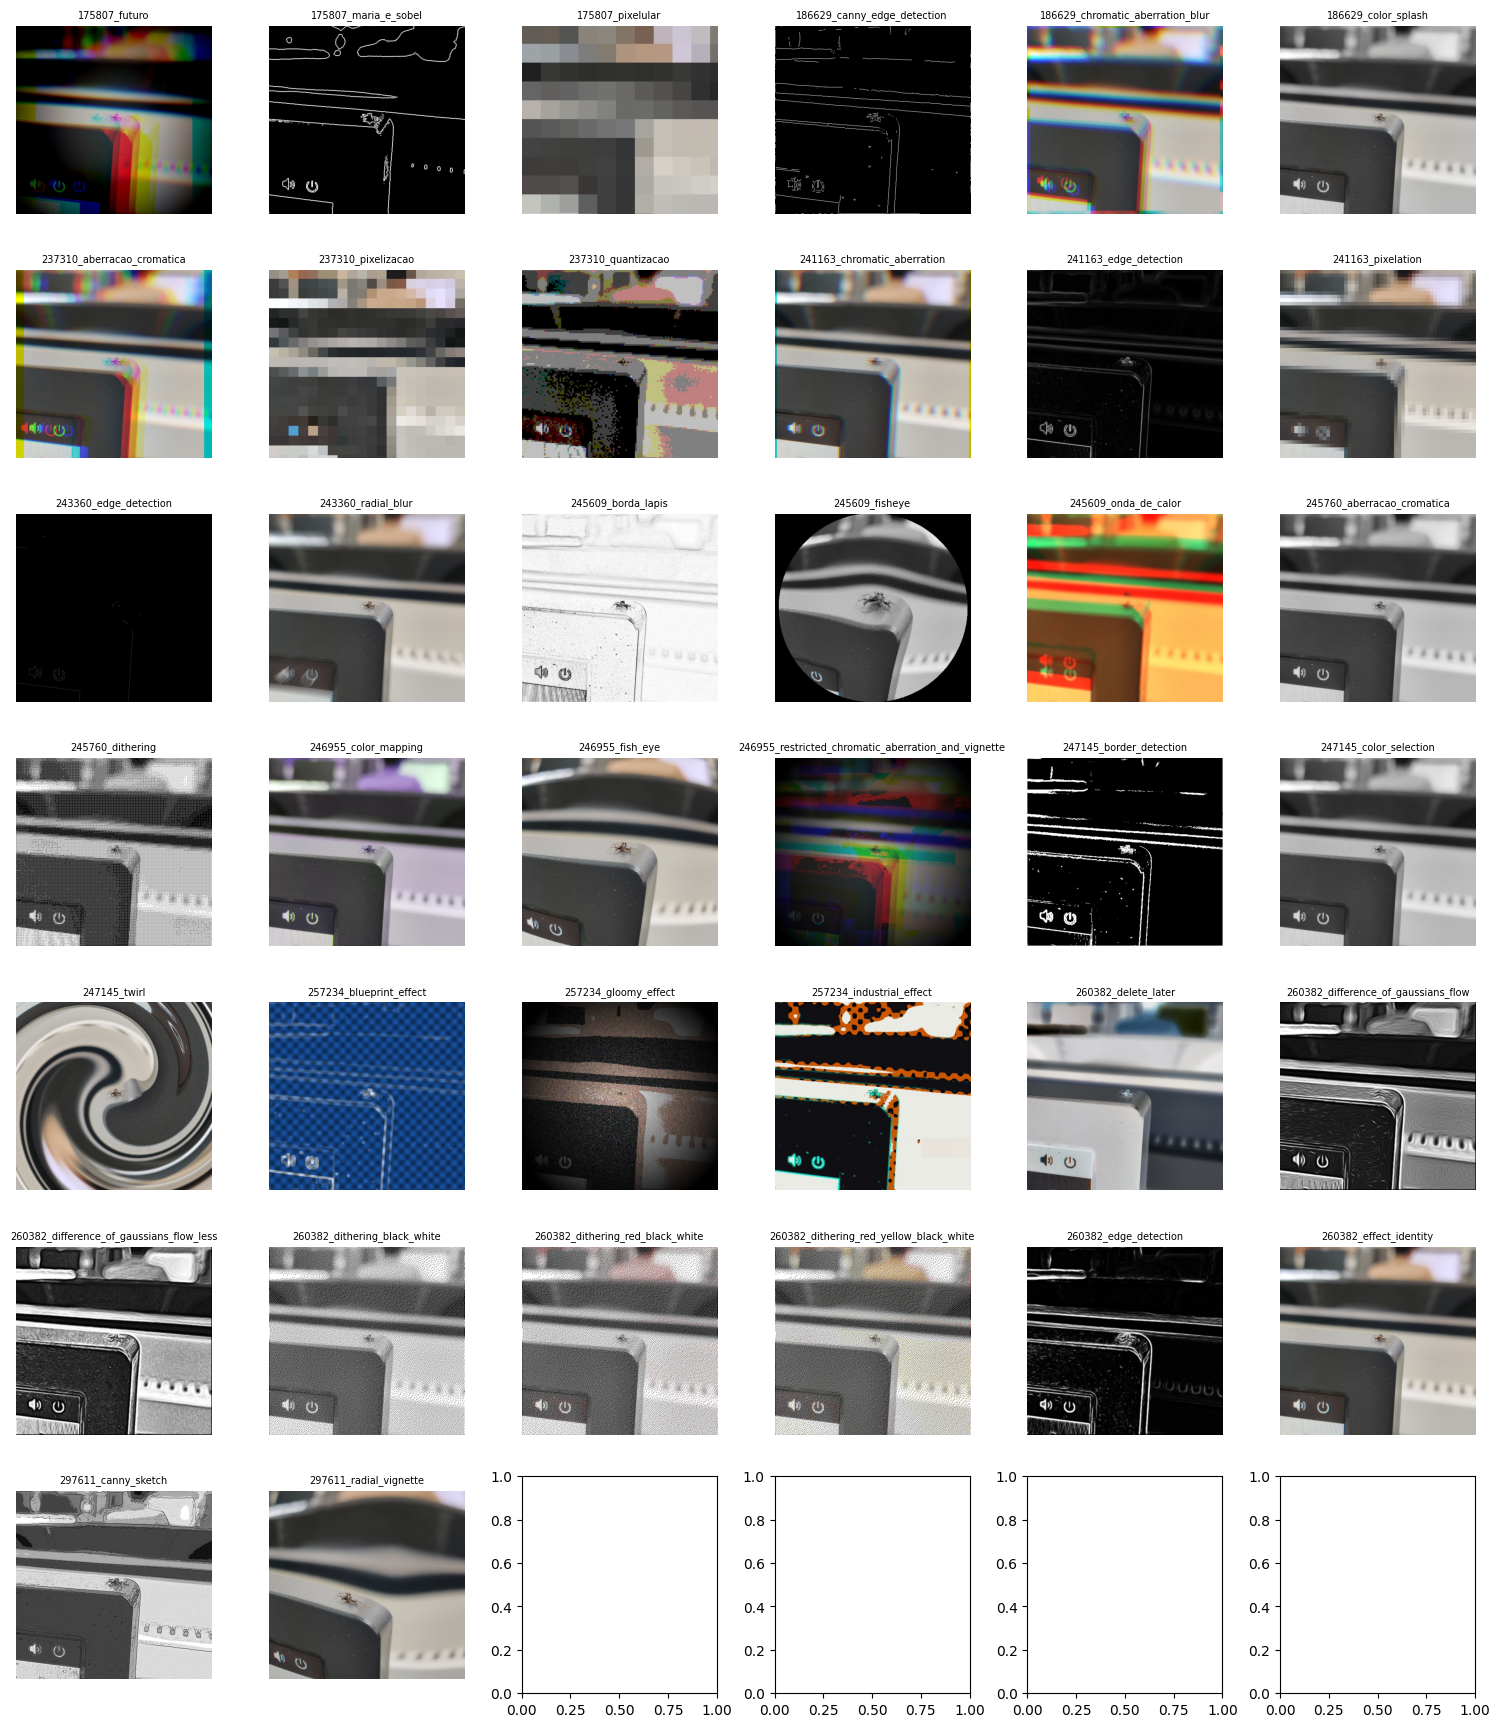

In [5]:
def plot_one_per_class(dataset, cols=6, figsize_per=2.5):                                    
    first = {}
    for entry in dataset.samples:
        path = entry[0]
        if len(entry) == 2:                      # ImageFolder: (path, class_idx)
            label = dataset.classes[entry[1]]
        else:                                    # PhotosDataset custom: (path, label, ...)
            label = entry[1]
        if label not in first:
            first[label] = path

    labels = sorted(first)
    n = len(labels)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*figsize_per, rows*figsize_per))       
    axes = axes.flat if n > 1 else [axes]
    for ax, label in zip(axes, labels):
        ax.imshow(Image.open(first[label]))
        ax.set_title(label, fontsize=7)
        ax.axis("off")
    for ax in list(axes)[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_one_per_class(dataset)

O plano era ver se tinha algum efeito estranho

## Análise exploratória com PCA
Aqui, foi feito uma tentativa de, por grupos de efeitos, construir, testar e selecionar features que conseguissem distinguir minimamente bem entre os tipos de efeitos daquele grupo.



In [ ]:
def run_pca_plot(X: np.ndarray, Y: np.ndarray, feature_names: list[str]) -> None:
    
    # Etapa fundamental no PCA para deixar todas as variáveis normalizadas quanto à variância.
    Xs = StandardScaler().fit_transform(X)

    pca = PCA(n_components=3).fit(Xs)
    pcs = pca.transform(Xs)
    print("var ratio:", pca.explained_variance_ratio_)
    print("cumulativo:", np.cumsum(pca.explained_variance_ratio_))

    # ---- scatter PC1xPC2 e PC2xPC3 ----
    unique_classes = sorted(set(Y))
    n = len(unique_classes)
    cmap = plt.get_cmap("tab10", n)
    colors = {cls: cmap(i) for i, cls in enumerate(unique_classes)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, (a, b) in zip(axes, [(0, 1), (1, 2)]):
        for cls in unique_classes:
            m = Y == cls
            ax.scatter(pcs[m, a], pcs[m, b], s=55, alpha=0.75,
                       label=cls, color=colors[cls])
        ax.set_xlabel(f"PC{a+1} ({pca.explained_variance_ratio_[a]:.1%})")
        ax.set_ylabel(f"PC{b+1} ({pca.explained_variance_ratio_[b]:.1%})")
        ax.set_title(f"PC{a+1} x PC{b+1}")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=9, loc="best")
    fig.suptitle("PCA", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ---- barras de loadings por componente ----
    n_feat = len(feature_names)
    fig, axes = plt.subplots(3, 1, figsize=(max(10, n_feat * 0.35), 10), sharex=True)
    for i, ax in enumerate(axes):
        loadings = pca.components_[i]
        bar_colors = ["tab:red" if v < 0 else "tab:blue" for v in loadings]
        ax.bar(range(n_feat), loadings, color=bar_colors)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_ylabel(f"PC{i+1}\n({pca.explained_variance_ratio_[i]:.1%})")
        ax.grid(alpha=0.3, axis="y")
    axes[-1].set_xticks(range(n_feat))
    axes[-1].set_xticklabels(feature_names, rotation=75, ha="right", fontsize=8)
    fig.suptitle("Loadings", fontsize=13)
    plt.tight_layout()
    plt.show()

In [25]:
def build_dataset(classes, feature_funcs, k_per_class, root="photos", seed=42):
    exts = (".jpg", ".jpeg", ".png")
    sets = []
    for cls in classes:
        d = os.path.join(root, cls)
        sets.append({f for f in os.listdir(d) if f.lower().endswith(exts)})
    common = sorted(set.intersection(*sets))
    if not common:
        raise ValueError("nenhum arquivo em comum entre as classes")
    print(f"arquivos em comum entre {len(classes)} classes: {len(common)}")
    chosen = random.Random(seed).sample(common, min(k_per_class, len(common)))

    rows, labels, feature_names = [], [], None
    for cls in classes:
        for fname in chosen:
            img = np.asarray(Image.open(os.path.join(root, cls, fname)).convert("RGB"))
            vals, names = [], []
            for fn in feature_funcs:
                v, n = fn(img)
                vals.extend(v); names.extend(n)
            if feature_names is None:
                feature_names = names
            rows.append(vals)
            labels.append(cls)

    return np.array(rows, dtype=np.float32), np.array(labels), feature_names

### Dithering

O efeito Dithering é a técnica de simular mais tons ou cores do que um sistema realmente suporta ao espalhar padrões de pixels ou ruído por toda a imagem. Dos efeitos listados um estava estranho.

245760_dithering
297611_green_railing_dither *
260382_dithering_black_white
260382_dithering_red_black_white
260382_dithering_red_yellow_black_white

In [ ]:
def feat_channel_percentiles(img, percentiles=(10, 25, 50, 75, 90)):
    vals, names = [], []
    for c, cname in zip(range(3), "RGB"):
        ch = img[..., c]
        ps = np.percentile(ch, percentiles) / 255.0
        vals.extend(ps.tolist())
        names.extend([f"{cname}_p{p}" for p in percentiles])
    return vals, names

def feat_histogram(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hist, _ = np.histogram(g, bins=32, range=(0, 256), density=True)
    p = hist / (hist.sum() + 1e-12)
    entropy = -np.sum(p[p > 0] * np.log2(p[p > 0]))
    peaks, _ = find_peaks(hist, height=0.005)
    rmean, gmean, bmean = img.reshape(-1, 3).mean(axis=0) / 255.0
    rstd, gstd, bstd = img.reshape(-1, 3).std(axis=0) / 255.0
    vals = [entropy, float(len(peaks)),
            hist[:4].sum(), hist[-4:].sum(), hist[12:20].sum(),
            rmean, gmean, bmean, rstd, gstd, bstd]
    names = ["hist_entropy", "hist_npeaks",
             "mass_dark", "mass_bright", "mass_mid",
             "R_mean", "G_mean", "B_mean", "R_std", "G_std", "B_std"]
    return vals, names

def feat_binariness(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    vals, names = [], []
    for lo, hi in [(15, 240), (30, 225), (50, 205)]:
        vals.append(((g < lo) | (g > hi)).mean())
        names.append(f"bin_{lo}_{hi}")
    for c, cname in zip(range(3), "RGB"):
        ch = img[..., c]
        vals.append(((ch < 25) | (ch > 230)).mean())
        names.append(f"{cname}_binariness")
    return vals, names

(240, 32) (240,)
var ratio: [0.44593337 0.2480715  0.10709962]
cumulativo: [0.44593337 0.6940049  0.80110455]


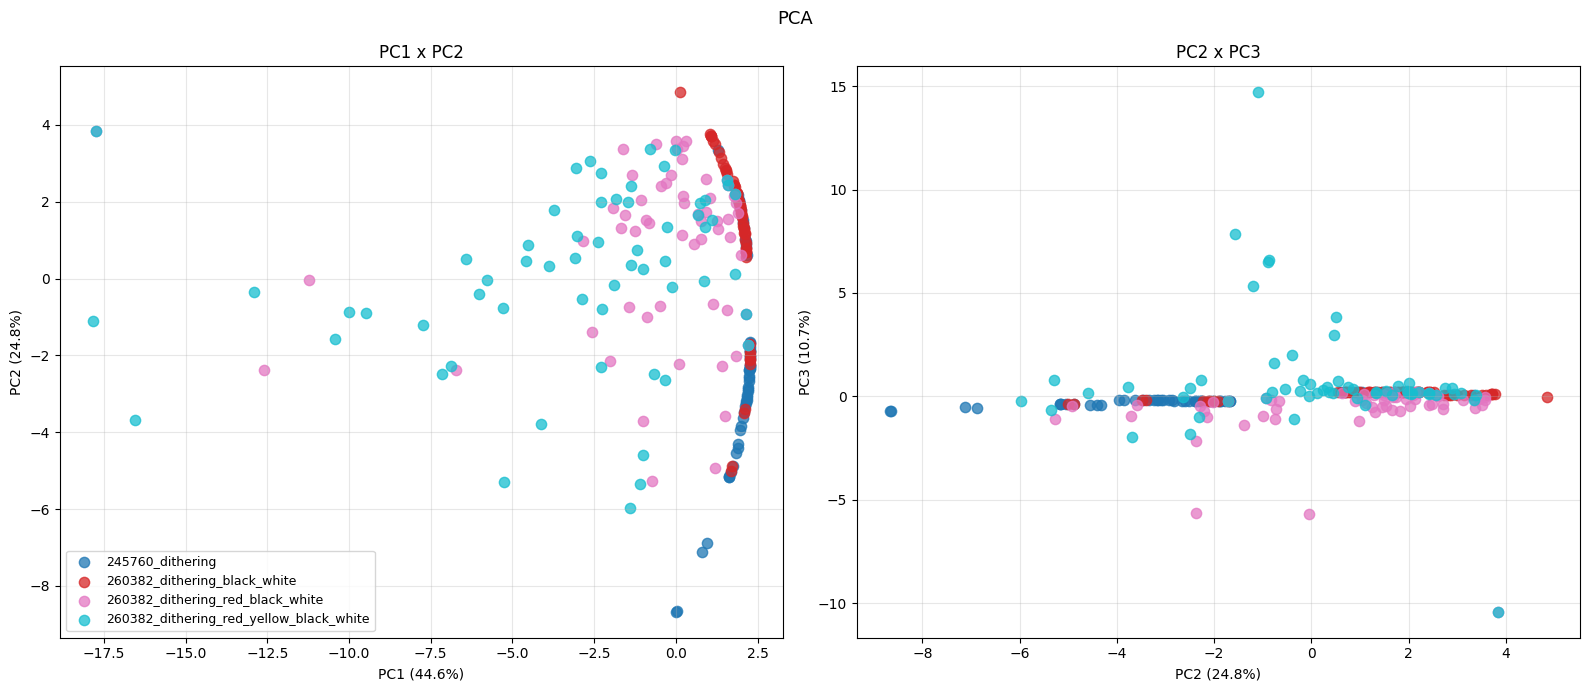

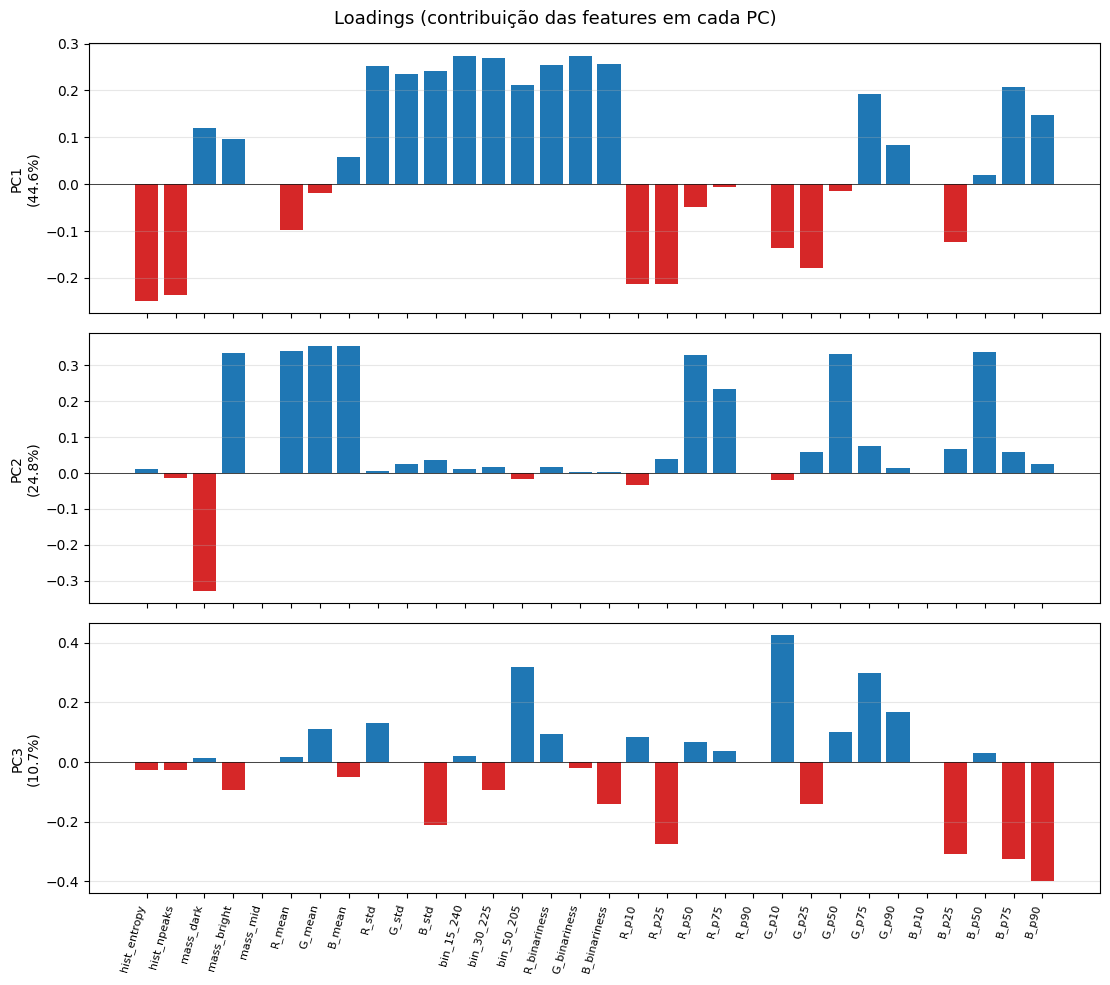

In [79]:
CLASSES = [
    "245760_dithering",
    "260382_dithering_black_white",
    "260382_dithering_red_black_white",
    "260382_dithering_red_yellow_black_white",
]

FEATURE_FUNCS = [feat_histogram, feat_binariness, feat_channel_percentiles]

X, y, feature_names = build_dataset(CLASSES, FEATURE_FUNCS, k_per_class=60)
print(X.shape, y.shape)
run_pca_plot(X, y, feature_names)

## Detecção de Bordas

175807_maria_e_sobel

186629_canny_edge_detection
241163_edge_detection
243360_edge_detection

247145_border_detection
260382_difference_of_gaussians_flow
260382_difference_of_gaussians_flow_less
260382_edge_detection

245760_deteccao_borda *

In [4]:
def feat_dither_palette(img):
    """Fração de pixels próximos a cores-alvo do dithering."""
    p = img.reshape(-1, 3).astype(np.float32)
    targets = {
        "black":  (0,   0,   0),
        "white":  (255, 255, 255),
        "red":    (255, 0,   0),
        "yellow": (255, 255, 0),
        "green":  (0,   255, 0),
    }
    vals, names = [], []
    tol = 60.0  # raio no espaço RGB
    for name, rgb in targets.items():
        d = np.linalg.norm(p - np.array(rgb, dtype=np.float32), axis=1)
        vals.append(float((d < tol).mean()))
        names.append(f"pal_{name}")
    # fração de pixels que NÃO são próximos de nenhuma cor-alvo
    covered = np.zeros(len(p), dtype=bool)
    for rgb in targets.values():
        covered |= np.linalg.norm(p - np.array(rgb, dtype=np.float32), axis=1) < tol
    vals.append(float((~covered).mean()))
    names.append("pal_other")
    return vals, names

def feat_unique_colors(img):
    """Tamanho efetivo da paleta — dithering tem pouquíssimas cores."""
    q = (img // 32).astype(np.int32)  # quantiza em 8 níveis/canal
    keys = q[..., 0] * 64 + q[..., 1] * 8 + q[..., 2]
    hist = np.bincount(keys.ravel(), minlength=512)
    total = hist.sum()
    sorted_h = np.sort(hist)[::-1]
    cum = np.cumsum(sorted_h) / total
    n90 = int(np.searchsorted(cum, 0.90)) + 1
    n99 = int(np.searchsorted(cum, 0.99)) + 1
    top2_frac = float(sorted_h[:2].sum()) / total
    top4_frac = float(sorted_h[:4].sum()) / total
    return [float(n90), float(n99), top2_frac, top4_frac], \
           ["n_colors_90", "n_colors_99", "top2_frac", "top4_frac"]

def feat_speckle(img):
    """Frequência de trocas de cor entre vizinhos — dithering = alta."""
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.int16)
    diff_h = np.abs(np.diff(g, axis=1))
    diff_v = np.abs(np.diff(g, axis=0))
    # fração de vizinhos com salto grande (típico de dithering binário)
    jump_h = (diff_h > 80).mean()
    jump_v = (diff_v > 80).mean()
    # energia total de alta frequência
    lap = cv2.Laplacian(g.astype(np.float32), cv2.CV_32F)
    lap_energy = float(np.abs(lap).mean())
    return [float(jump_h), float(jump_v), lap_energy], \
           ["speckle_h", "speckle_v", "laplacian_energy"]

def feat_fft_highfreq(img):
    """Razão energia alta/baixa frequência — dithering concentra em alta."""
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    F = np.fft.fftshift(np.abs(np.fft.fft2(g)))
    h, w = g.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.indices((h, w))
    r = np.hypot(xx - cx, yy - cy) / max(cy, cx)
    low  = F[r < 0.15].sum()
    high = F[r > 0.5].sum()
    mid  = F[(r >= 0.15) & (r <= 0.5)].sum()
    total = low + mid + high + 1e-6
    return [float(high / total), float(low / total), float(high / (low + 1e-6))], \
           ["fft_high_frac", "fft_low_frac", "fft_high_over_low"]

(240, 16) (240,)
var ratio: [0.5077835 0.3075629 0.0957825]
cumulativo: [0.5077835  0.81534636 0.9111289 ]


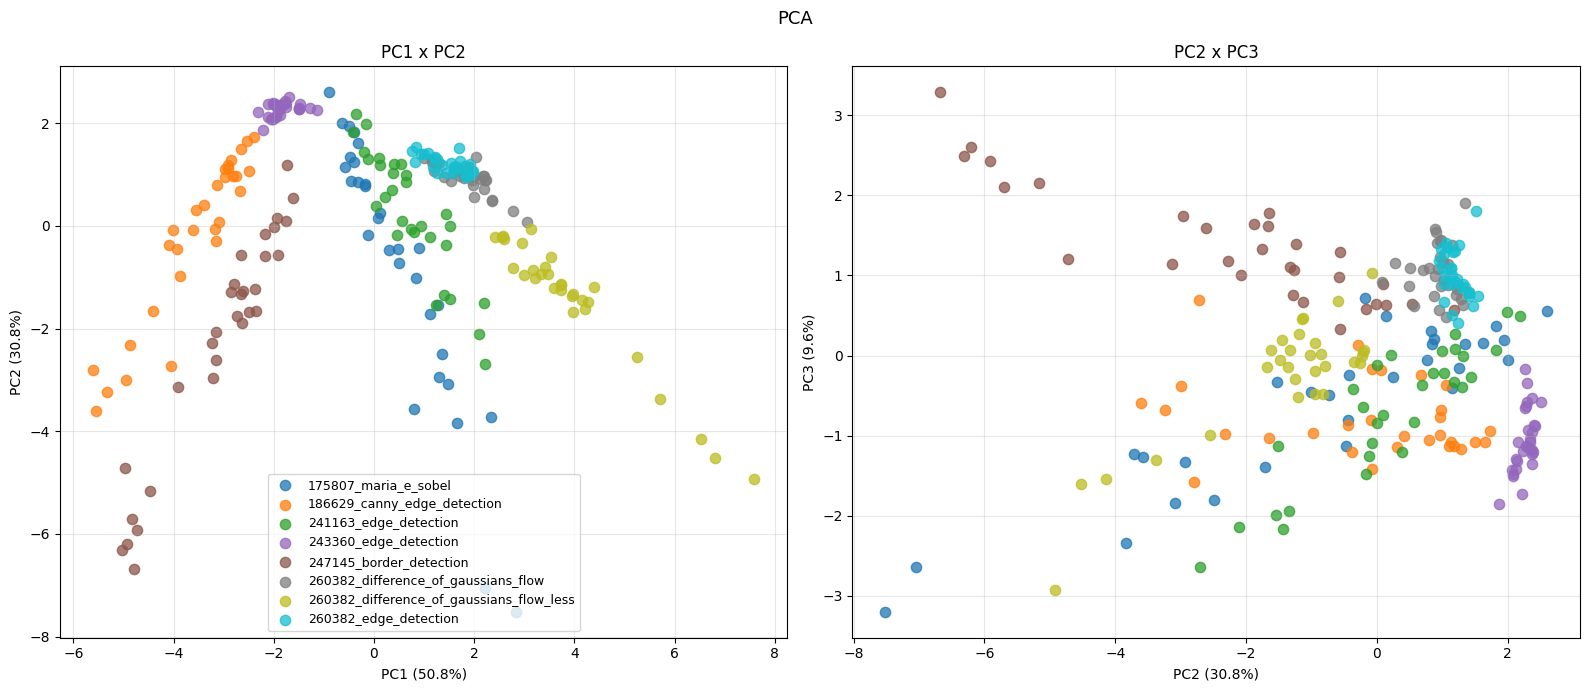

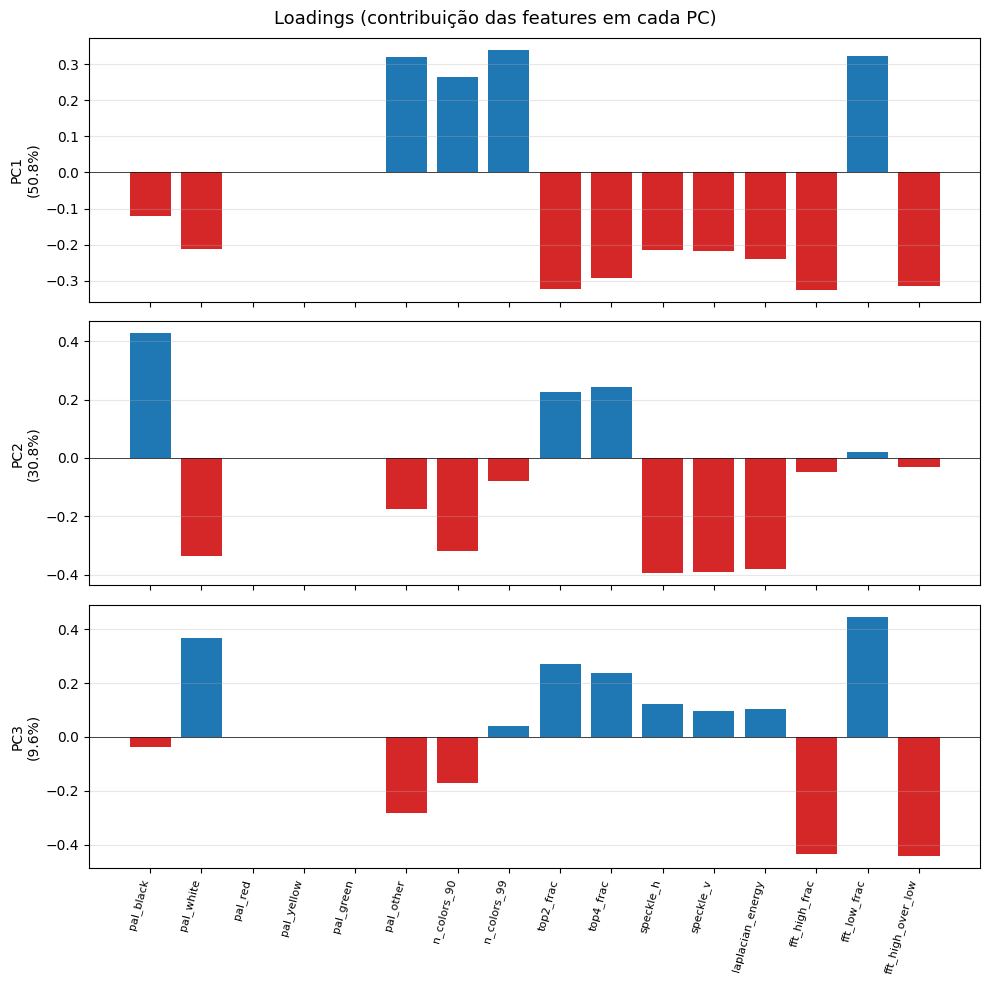

In [ ]:
CLASSES = [
    "175807_maria_e_sobel",
    "186629_canny_edge_detection",
    "241163_edge_detection",
    "243360_edge_detection",
    "247145_border_detection",
    "260382_difference_of_gaussians_flow",
    "260382_difference_of_gaussians_flow_less",
    "260382_edge_detection",
]


FEATURE_FUNCS = [feat_dither_palette, feat_unique_colors, feat_speckle, feat_fft_highfreq]

X, y, feature_names = build_dataset(CLASSES, FEATURE_FUNCS, k_per_class=30)
print(X.shape, y.shape)
run_pca_plot(X, y, feature_names)

## Aberração cromática

245760_aberracao_cromatica * 
186629_chromatic_aberration_blur
237310_aberracao_cromatica
241163_chromatic_aberration
243360_chromatic_aberration * 
246955_restricted_chromatic_aberration_and_vignette


In [12]:

def feat_channel_balance(img):
    r, g, b = img[..., 0].mean(), img[..., 1].mean(), img[..., 2].mean()
    total = r + g + b + 1e-6
    vals = [r/total, g/total, b/total,
            (r - g) / 255, (r - b) / 255, (g - b) / 255]
    names = ["r_ratio", "g_ratio", "b_ratio", "rg_diff", "rb_diff", "gb_diff"]
    return vals, names

def feat_saturation(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    s = hsv[..., 1] / 255.0
    vals = [s.mean(), s.std(), (s < 0.1).mean(), (s > 0.5).mean()]
    names = ["sat_mean", "sat_std", "frac_gray", "frac_saturated"]
    return vals, names

def feat_ring_variance(img, n_rings=5):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    h, w = g.shape
    cy, cx = h / 2, w / 2
    yy, xx = np.indices((h, w))
    r = np.hypot(xx - cx, yy - cy)
    r_norm = r / r.max()
    vals, names = [], []
    for i in range(n_rings):
        lo, hi = i / n_rings, (i + 1) / n_rings
        ring = g[(r_norm >= lo) & (r_norm < hi)]
        vals.append(float(ring.std()) if len(ring) else 0.0)
        names.append(f"ring_std_{i}")
    return vals, names

def feat_radial_alignment(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.hypot(gx, gy)

    h, w = g.shape
    cy, cx = h / 2, w / 2
    yy, xx = np.indices((h, w))
    rx, ry = xx - cx, yy - cy
    r = np.hypot(rx, ry) + 1e-6
    rx, ry = rx / r, ry / r   # vetor radial unitário

    # ângulo entre gradiente e vetor radial (via cos e sin)
    gnorm = mag + 1e-6
    cos = (gx * rx + gy * ry) / gnorm        # alinhamento radial
    sin = (gx * (-ry) + gy * rx) / gnorm     # alinhamento tangencial

    # pondera por magnitude (só bordas fortes importam)
    mask = mag > mag.mean()
    if mask.sum() == 0:
        return [0.0, 0.0, 0.0], ["radial_align", "tangential_align", "twirl_bias"]

    radial = np.abs(cos[mask]).mean()
    tangential = np.abs(sin[mask]).mean()
    # bias = média assinada de sin → detecta twirl (rotação consistente)
    twirl_bias = sin[mask].mean()

    return [float(radial), float(tangential), float(twirl_bias)], \
           ["radial_align", "tangential_align", "twirl_bias"]

def feat_channel_shift(img):
    r = img[..., 0].astype(np.float32)
    g = img[..., 1].astype(np.float32)
    b = img[..., 2].astype(np.float32)

    # correlação de fase devolve (dx, dy) do deslocamento de r/b relativo a g
    shift_rg, _ = cv2.phaseCorrelate(r, g)
    shift_bg, _ = cv2.phaseCorrelate(b, g)

    dx_rg, dy_rg = shift_rg
    dx_bg, dy_bg = shift_bg

    mag_rg = float(np.hypot(dx_rg, dy_rg))
    mag_bg = float(np.hypot(dx_bg, dy_bg))

    vals = [mag_rg, mag_bg, mag_rg + mag_bg,
            float(dx_rg), float(dy_rg), float(dx_bg), float(dy_bg)]
    names = ["shift_rg_mag", "shift_bg_mag", "shift_total",
             "dx_rg", "dy_rg", "dx_bg", "dy_bg"]
    return vals, names

def feat_center_vs_edge(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) / 255.0
    h, w = g.shape
    cy, cx = h // 2, w // 2
    # disco central (25% do raio) e anel externo (>75% do raio)
    yy, xx = np.indices((h, w))
    r = np.hypot(xx - cx, yy - cy)
    r_norm = r / r.max()
    center = g[r_norm < 0.25]
    edge = g[r_norm > 0.75]
    vals = [
        center.mean(), edge.mean(),
        center.mean() - edge.mean(),     # positivo = bordas escuras (vinheta/fisheye)
        center.std(), edge.std(),
    ]
    names = ["lum_center", "lum_edge", "center_minus_edge",
             "std_center", "std_edge"]
    return vals, names

(150, 20) (150,)
var ratio: [0.67834836 0.1655419  0.04212842]
cumulativo: [0.67834836 0.84389025 0.8860187 ]


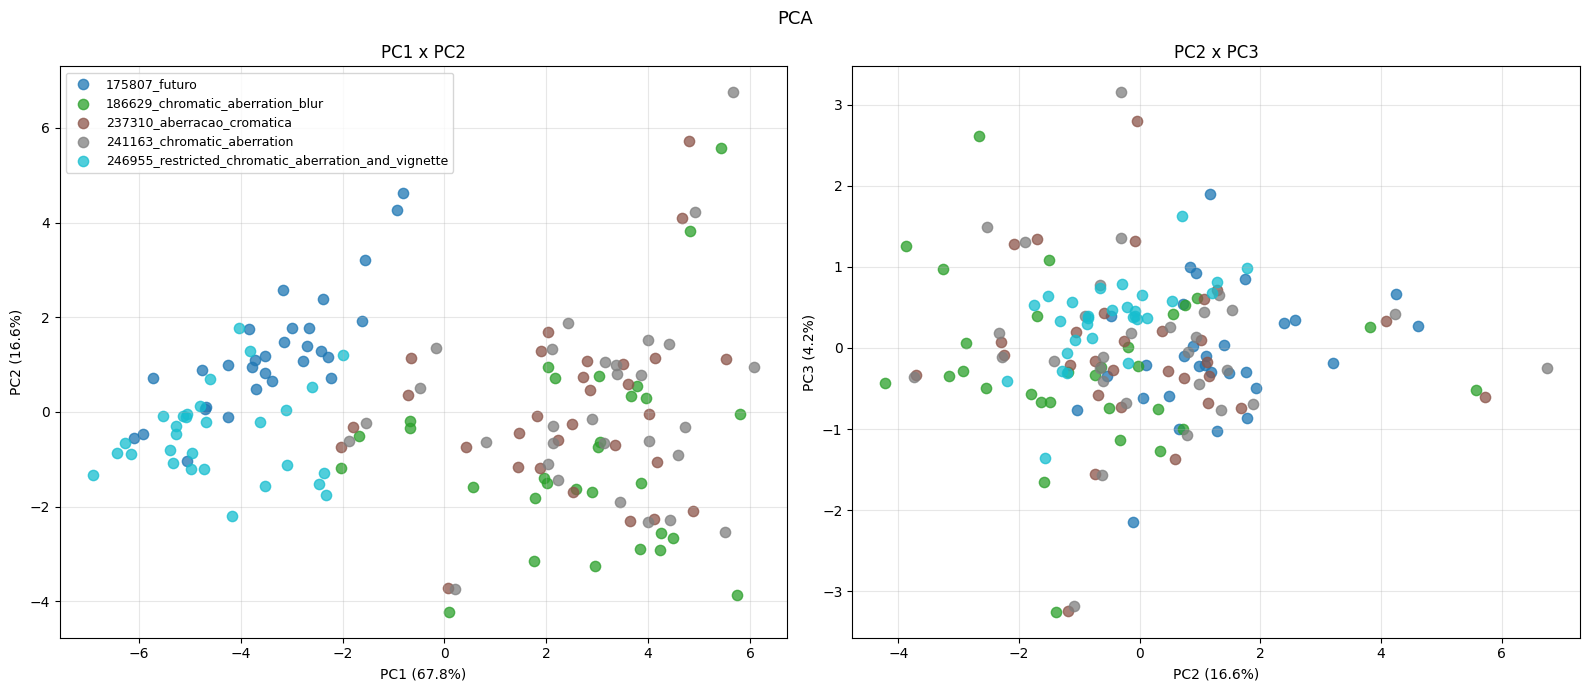

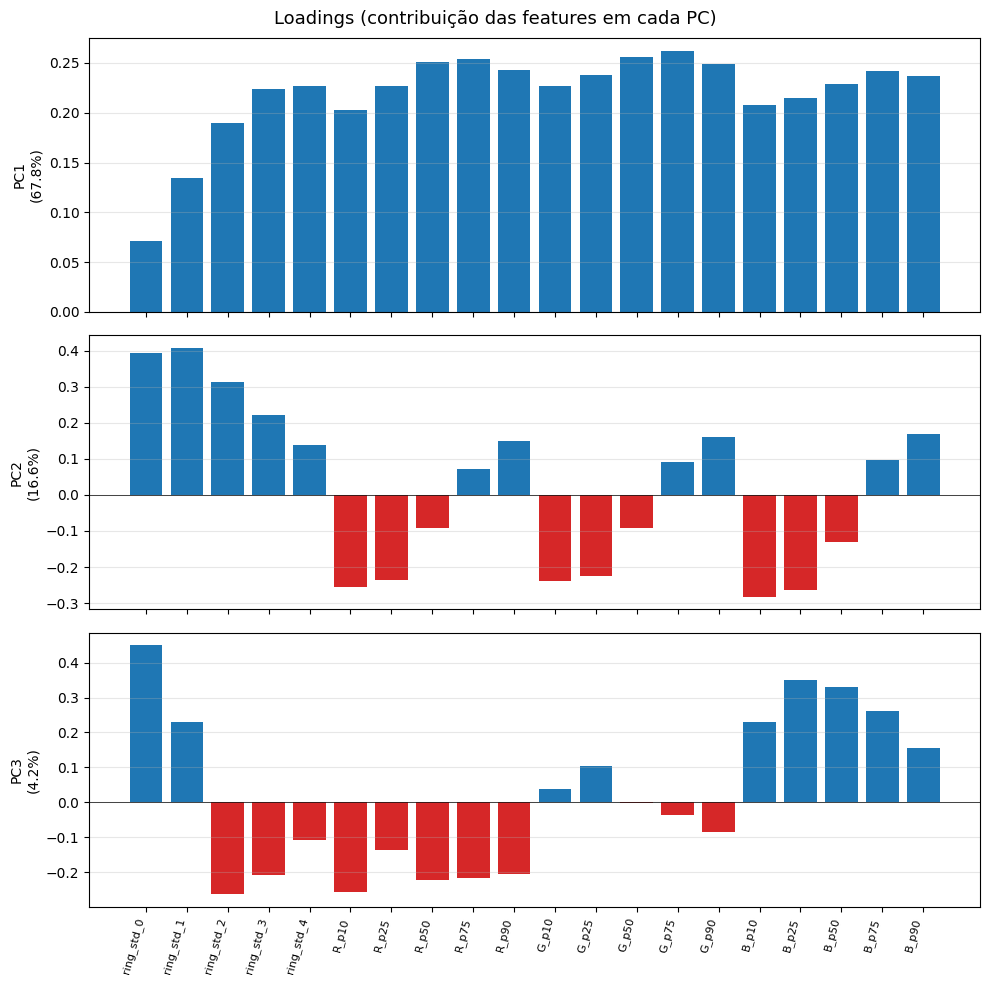

In [ ]:
CLASSES = [
    "175807_futuro",
    "186629_chromatic_aberration_blur",
    "237310_aberracao_cromatica",
    "241163_chromatic_aberration",
    "246955_restricted_chromatic_aberration_and_vignette",
]

# CLASSES = [
#     "186629_chromatic_aberration_blur",
#     "237310_aberracao_cromatica",
#     "241163_chromatic_aberration",
# ]


FEATURE_FUNCS = [feat_ring_variance, feat_channel_percentiles]

X, y, feature_names = build_dataset(CLASSES, FEATURE_FUNCS, k_per_class=30)
print(X.shape, y.shape)
run_pca_plot(X, y, feature_names)

## Pixelização/Quantização

In [19]:
def feat_palette_size(img):
    # histograma 3D em buckets grossos
    q = (img // 16).astype(np.int32)          # 16 níveis por canal
    keys = q[..., 0] * 256 + q[..., 1] * 16 + q[..., 2]
    hist = np.bincount(keys.ravel(), minlength=16**3)

    total = hist.sum()
    filled = (hist > 0).sum()                  # bins ocupados
    # cores que cobrem 95% da imagem (paleta "efetiva")
    sorted_h = np.sort(hist)[::-1]
    cum = np.cumsum(sorted_h) / total
    n95 = int(np.searchsorted(cum, 0.95)) + 1
    # entropia do histograma de cor
    p = hist[hist > 0] / total
    entropy = float(-np.sum(p * np.log2(p)))

    vals = [float(filled) / 4096, float(n95), entropy,
            float(sorted_h[0]) / total]       # fração da cor dominante
    names = ["color_bins_filled", "colors_95pct",
             "color_entropy", "dominant_color_frac"]
    return vals, names

def feat_pixelation_block(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
    h, w = g.shape

    # fração de pixels iguais ao vizinho (horizontal e vertical)
    same_h = (np.abs(np.diff(g, axis=1)) < 2).mean()
    same_v = (np.abs(np.diff(g, axis=0)) < 2).mean()

    # estima tamanho do bloco: quantos pixels consecutivos em média têm o mesmo valor numa linha
    row = g[h // 2]
    changes = np.where(np.abs(np.diff(row)) > 2)[0]
    if len(changes) > 1:
        run_lengths = np.diff(changes)
        mean_run = float(run_lengths.mean())
    else:
        mean_run = float(w)

    vals = [float(same_h), float(same_v), mean_run / w]
    names = ["same_neighbor_h", "same_neighbor_v", "mean_run_len_norm"]
    return vals, names

(150, 7) (150,)
var ratio: [0.603339   0.22009042 0.09175574]
cumulativo: [0.603339   0.82342947 0.9151852 ]


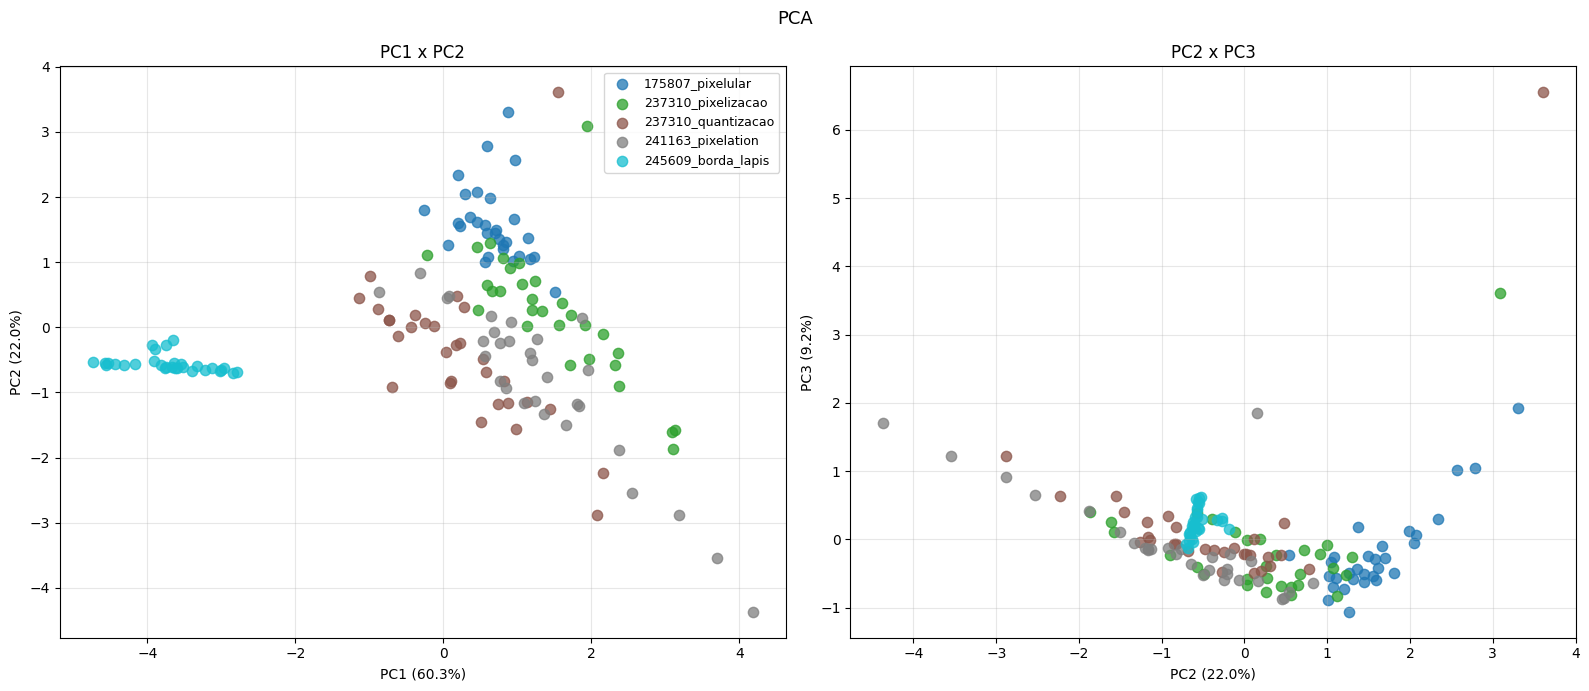

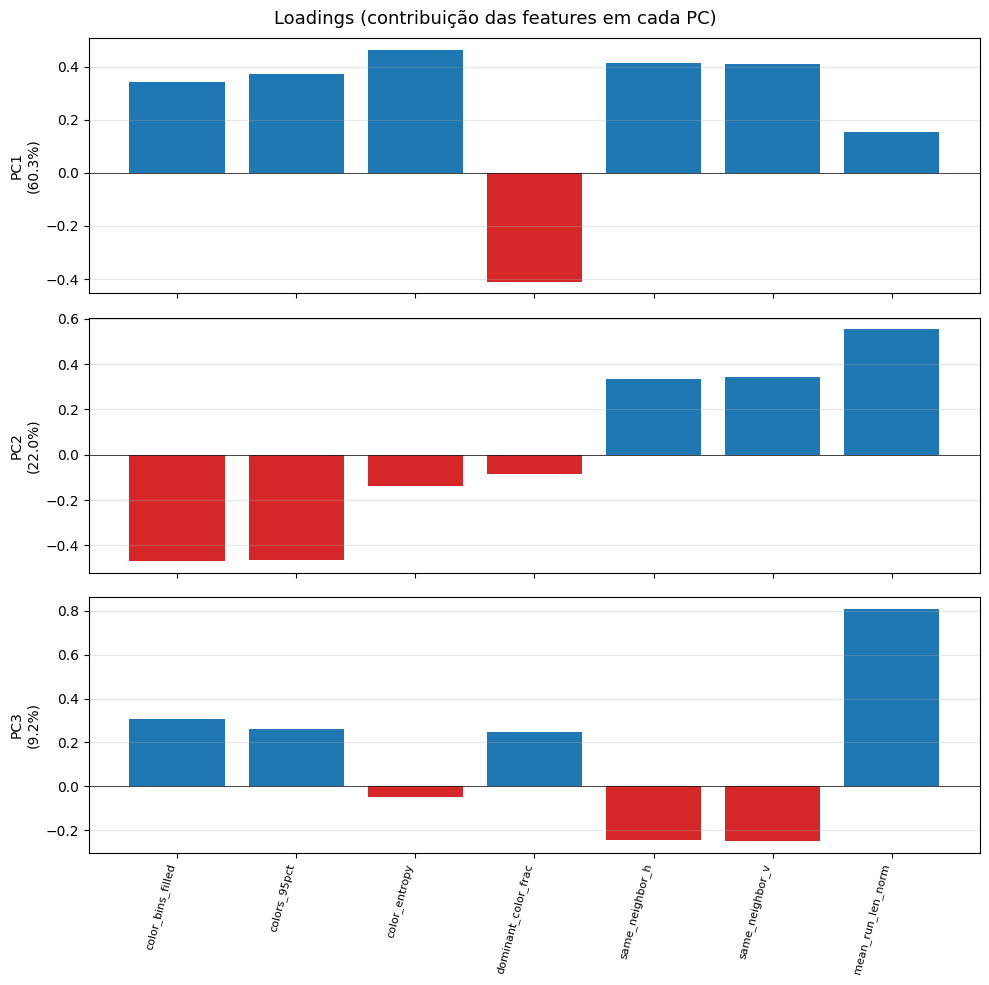

In [ ]:
CLASSES = [
    "175807_pixelular",
    "237310_pixelizacao",
    "237310_quantizacao",
    "241163_pixelation",
]

FEATURE_FUNCS = [feat_palette_size, feat_pixelation_block]


X, y, feature_names = build_dataset(CLASSES, FEATURE_FUNCS, k_per_class=30)
print(X.shape, y.shape)
run_pca_plot(X, y, feature_names)


## Efeitos de cor

In [28]:
def feat_hue_stats(img):
    """Distribuição de matiz — separa blueprint (azul), heat (vermelho), futuro (tint)."""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h = hsv[..., 0].astype(np.float32)      # 0..179 no OpenCV
    s = hsv[..., 1] / 255.0
    # só conta hue de pixels coloridos
    mask = s > 0.15
    if mask.sum() < 50:
        return [0.0] * 8, ["hue_red", "hue_orange", "hue_yellow", "hue_green",
                           "hue_cyan", "hue_blue", "hue_magenta", "hue_dominant_frac"]
    hh = h[mask]
    # bins circulares: 6 faixas de 30° (OpenCV: 0..179 → mult por 2)
    edges = [(0, 10), (10, 20), (20, 35), (35, 80), (80, 100), (100, 130), (130, 170)]
    counts = []
    for lo, hi in edges[:6]:
        counts.append(float(((hh >= lo) & (hh < hi)).mean()))
    # dominância da faixa mais frequente
    hist, _ = np.histogram(hh, bins=18, range=(0, 180))
    dom = float(hist.max() / (hist.sum() + 1e-6))
    return counts + [dom, float(mask.mean())], \
           ["hue_red", "hue_orange", "hue_yellow", "hue_green",
            "hue_cyan", "hue_blue", "hue_dominant_frac", "colored_frac"]

def feat_saturation_bimodal(img):
    """Bimodalidade de saturação — color_splash tem um pico em 0 e outro alto."""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    s = hsv[..., 1] / 255.0
    # massa nos extremos vs meio
    low_mass  = float((s < 0.1).mean())
    high_mass = float((s > 0.6).mean())
    mid_mass  = float(((s >= 0.1) & (s <= 0.6)).mean())
    # "splash score": alto quando coexistem muitos cinzas e alguns muito saturados
    splash = low_mass * high_mass * 4  # em [0,1]
    return [low_mass, mid_mass, high_mass, splash], \
           ["sat_low", "sat_mid", "sat_high", "splash_score"]

arquivos em comum entre 8 classes: 183
(240, 32) (240,)
var ratio: [0.4740137  0.21829125 0.12263315]
cumulativo: [0.4740137  0.69230497 0.8149381 ]


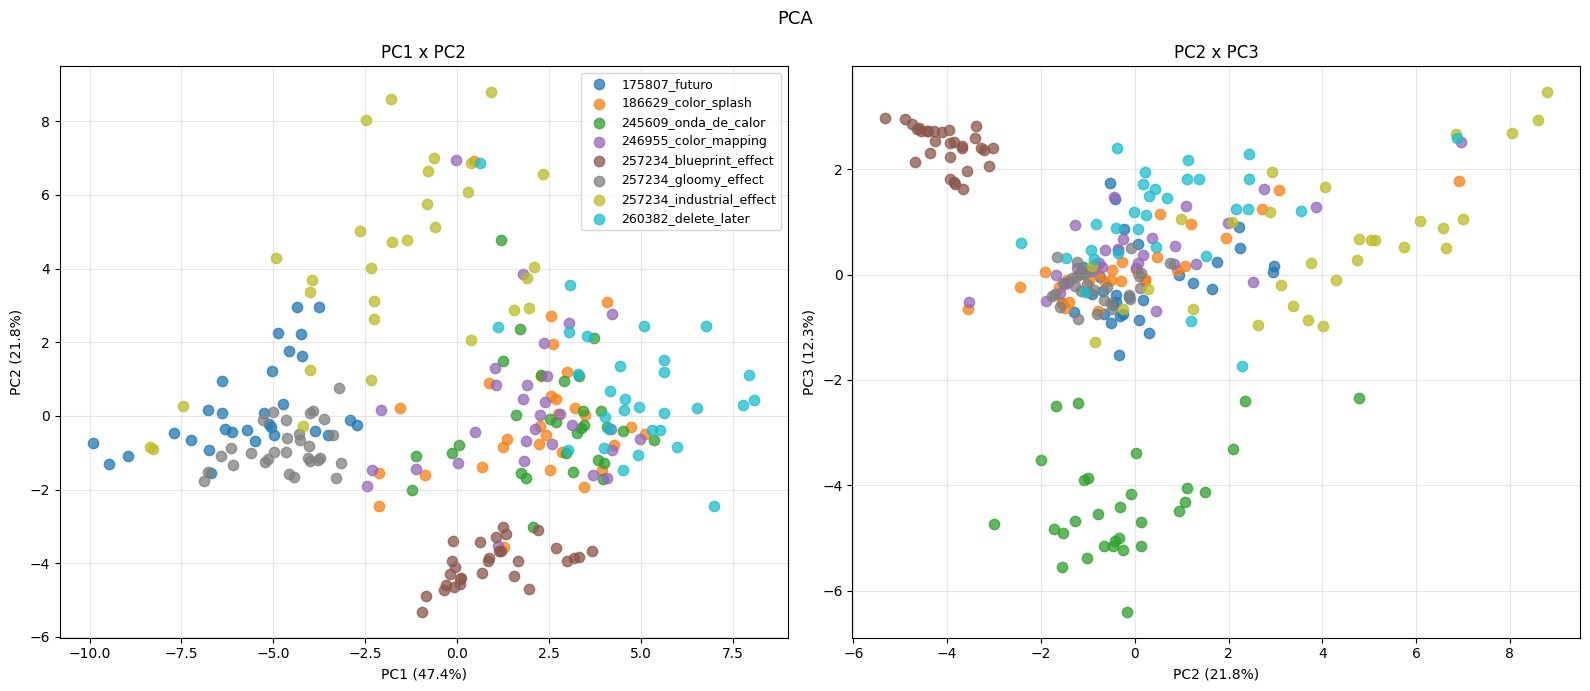

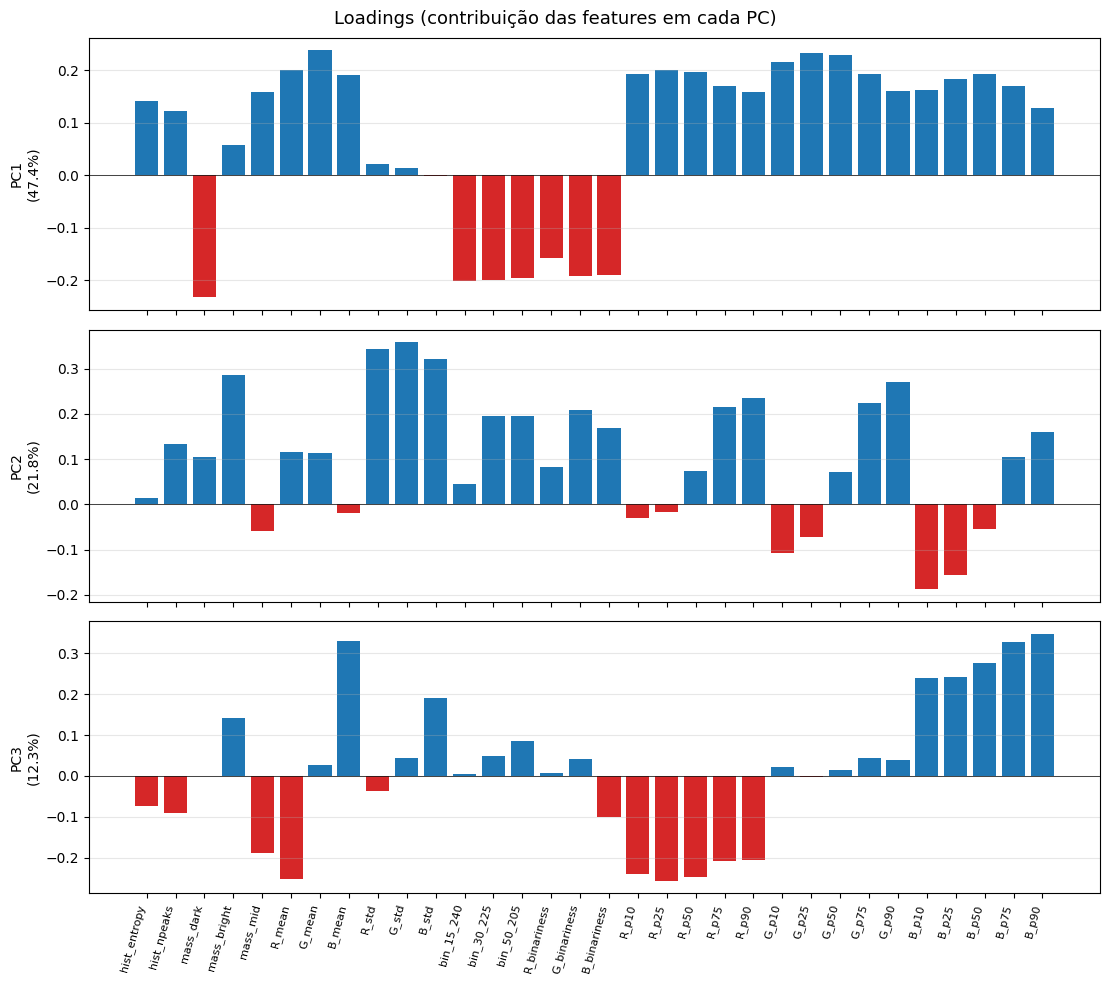

In [ ]:
CLASSES = [
    "246955_color_mapping",
    "186629_color_splash",
    "245609_onda_de_calor",
    "257234_blueprint_effect",
    "257234_industrial_effect",
    "257234_gloomy_effect",
    "175807_futuro",
    "260382_delete_later",
]

FEATURE_FUNCS = [feat_histogram, feat_binariness, feat_channel_percentiles]

X, y, feature_names = build_dataset(CLASSES, FEATURE_FUNCS, k_per_class=30)
print(X.shape, y.shape)
run_pca_plot(X, y, feature_names)

## Efeitos de geométricos (twirl, fisheye, vinheta)

In [33]:
def feat_ring_edge_density(img, n_rings=4):
    """Densidade de bordas por anel concêntrico.
    - fisheye: alta densidade nos anéis externos (conteúdo comprimido)
    - radial_vignette: baixa densidade nos externos (escuro → Canny não dispara)
    - radial_blur: baixa densidade nos externos (bordas borradas)
    """
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(g, 50, 150) > 0
    h, w = g.shape
    cy, cx = h / 2, w / 2
    yy, xx = np.indices((h, w))
    r = np.hypot(xx - cx, yy - cy)
    r_norm = r / r.max()
    vals, names = [], []
    for i in range(n_rings):
        lo, hi = i / n_rings, (i + 1) / n_rings
        mask = (r_norm >= lo) & (r_norm < hi)
        d = float(edges[mask].mean()) if mask.any() else 0.0
        vals.append(d)
        names.append(f"edge_density_ring_{i}")
    # razão externo/interno — discriminante compacto
    vals.append(vals[-1] / (vals[0] + 1e-6))
    names.append("edge_ring_outer_over_inner")
    return vals, names

arquivos em comum entre 5 classes: 183
(150, 14) (150,)
var ratio: [0.4472653  0.23808786 0.09941173]
cumulativo: [0.4472653  0.68535316 0.7847649 ]


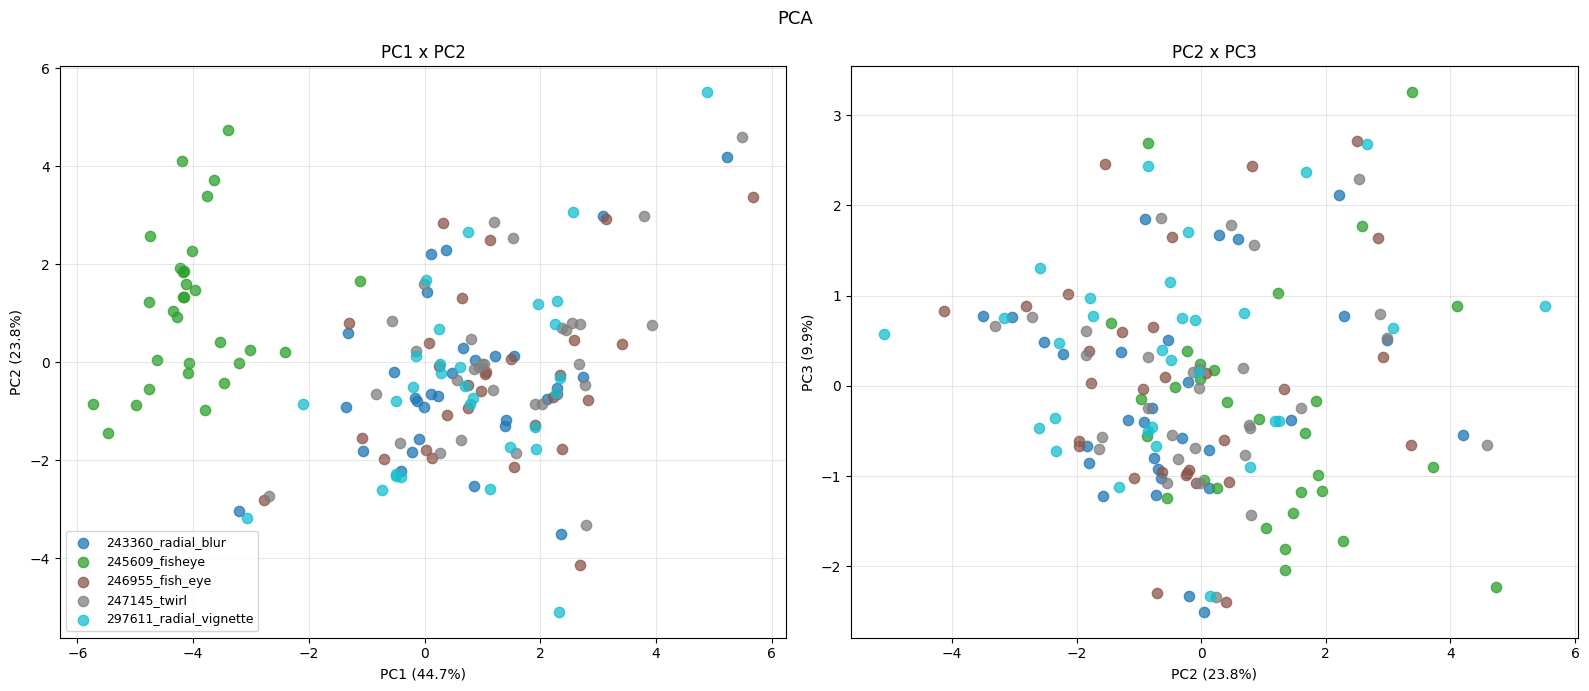

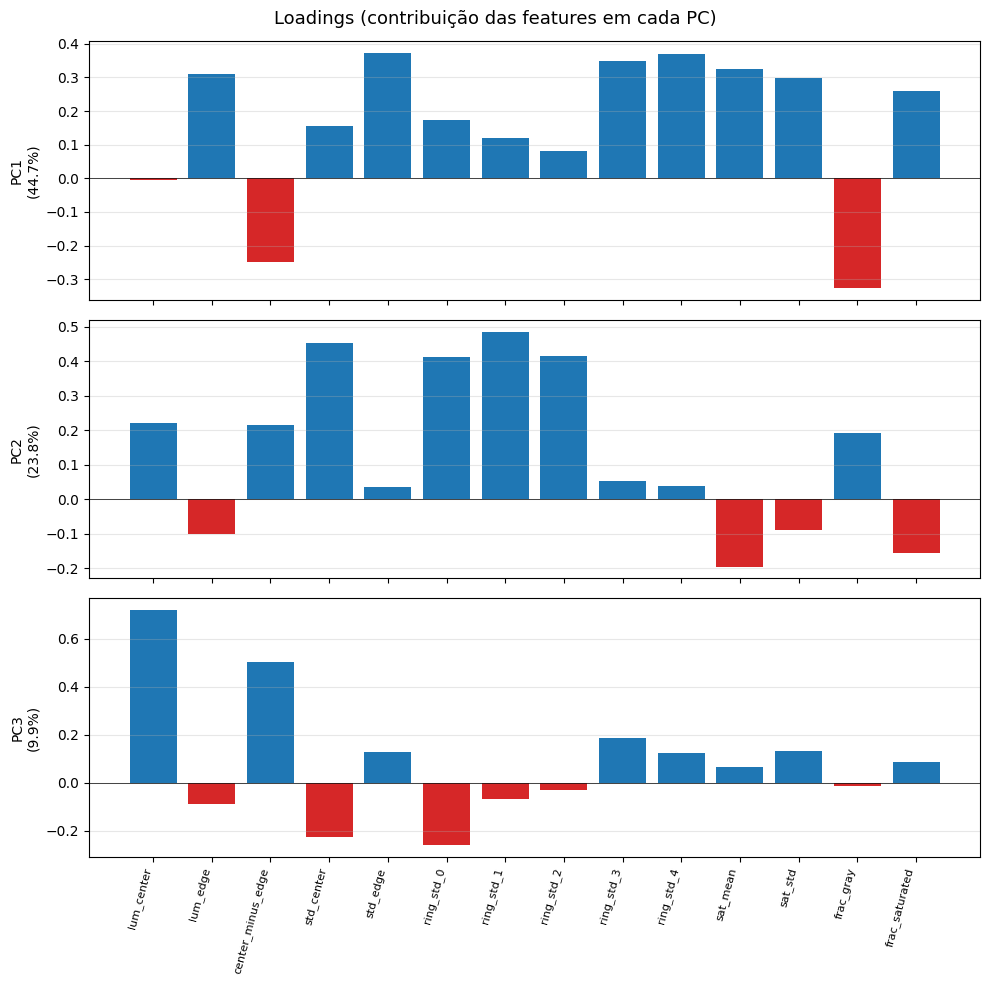

In [ ]:
CLASSES = [
    "246955_fish_eye",
    "247145_twirl",
    "297611_radial_vignette",
    "245609_fisheye",
    "243360_radial_blur",
]

FEATURE_FUNCS = [
    feat_center_vs_edge,
    feat_ring_variance,
    feat_saturation,
]



X, y, feature_names = build_dataset(CLASSES, FEATURE_FUNCS, k_per_class=30)
print(X.shape, y.shape)
run_pca_plot(X, y, feature_names)

# Construção do Dataset

In [36]:
ALL_FEATURE_FUNCS = [
    feat_channel_percentiles,
    feat_histogram,
    feat_binariness,
    feat_channel_balance,
    feat_saturation,
    feat_ring_variance,
    feat_radial_alignment,
    feat_channel_shift,
    feat_center_vs_edge,
    feat_palette_size,
    feat_pixelation_block,
    feat_dither_palette,
    feat_unique_colors,
    feat_speckle,
    feat_fft_highfreq
]

In [39]:
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm

class FeatureDataset(Dataset):
    def __init__(self, root, feature_funcs, img_size=200):
        self.base = datasets.ImageFolder(root=root)
        self.feature_funcs = feature_funcs
        self.classes = self.base.classes
        self.img_size = img_size
        # descobre nomes das features numa imagem de exemplo (já no tamanho reduzido)
        img = self._load(self.base.samples[0][0])
        names = []
        for fn in feature_funcs:
            _, n = fn(img)
            names.extend(n)
        self.feature_names = names

    def _load(self, path):
        img = Image.open(path).convert("RGB")
        if self.img_size is not None:
            img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        return np.asarray(img)

    def __len__(self):
        return len(self.base.samples)

    def __getitem__(self, i):
        path, label = self.base.samples[i]
        img = self._load(path)
        vals = []
        for fn in self.feature_funcs:
            v, _ = fn(img)
            vals.extend(v)
        return torch.tensor(vals, dtype=torch.float32), label

feat_ds = FeatureDataset("photos", ALL_FEATURE_FUNCS, img_size=200)
loader = DataLoader(feat_ds, batch_size=128, shuffle=False,
                    num_workers=4, persistent_workers=True)

X_list, y_list = [], []
for xb, yb in tqdm(loader, desc="extraindo"):
    X_list.append(xb.numpy())
    y_list.append(yb.numpy())

X_all = np.concatenate(X_list, axis=0)
y_idx = np.concatenate(y_list, axis=0)
y_all = np.array([feat_ds.classes[i] for i in y_idx])
feature_names = feat_ds.feature_names

print(X_all.shape, y_all.shape, "features:", len(feature_names))
np.savez("features_cache.npz", X=X_all, y=y_all,
         feature_names=np.array(feature_names))

extraindo: 100%|██████████| 52/52 [01:23<00:00,  1.61s/it]

(6588, 85) (6588,) features: 85


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_all_encoded = label_encoder.fit_transform(y_all)
class_names = label_encoder.classes_

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all_encoded, test_size=0.2, stratify=y_all_encoded, random_state=42
)
print("train:", X_tr.shape, "test:", X_te.shape)
print("classes:", len(class_names))

train: (5270, 85) test: (1318, 85)
classes: 36


# Algoritmo não supervisionado

# Algoritmo supervisionado

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Estabelece um pipeline de análise, primeiro normalizando e depois aplicando o KNN
pipe = Pipeline([
    ("pca", PCA()),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

# Dicionário de hiperparâmetros a serem testados: quantidade de vizinhos, peso nos votos dos vizinhos e a métrica utilizada
param_grid = {
    "pca__n_components": [3, 5, 10, 20, 30],
    "knn__n_neighbors": [1, 3, 5, 7, 11, 15, 25],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

grid = GridSearchCV(
    pipe, param_grid,
    scoring="f1_macro", # métrica de seleção
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), # Treinamento com validação cruzada usando 5 folds
    n_jobs=-1,
    refit=True, # Re-treina com os melhores parâmetros utilizados
    return_train_score=True,
)
grid.fit(X_tr, y_tr)

print("melhores params:", grid.best_params_)
print(f"f1_macro CV:    {grid.best_score_:.3f}")

melhores params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform', 'pca__n_components': 30}
f1_macro CV:    0.767


{'accuracy': 0.7769347496206374, 'precision': 0.7831349567661694, 'recall': 0.7765890890890892, 'f1_macro': 0.7734722927234957}
                                                     precision    recall  f1-score   support

                                      175807_futuro       1.00      0.94      0.97        36
                               175807_maria_e_sobel       0.82      0.84      0.83        37
                                   175807_pixelular       0.92      0.89      0.90        37
                        186629_canny_edge_detection       1.00      0.97      0.99        37
                   186629_chromatic_aberration_blur       1.00      1.00      1.00        36
                                186629_color_splash       0.43      0.86      0.58        37
                         237310_aberracao_cromatica       0.97      0.84      0.90        37
                                 237310_pixelizacao       0.87      0.89      0.88        37
                                 2

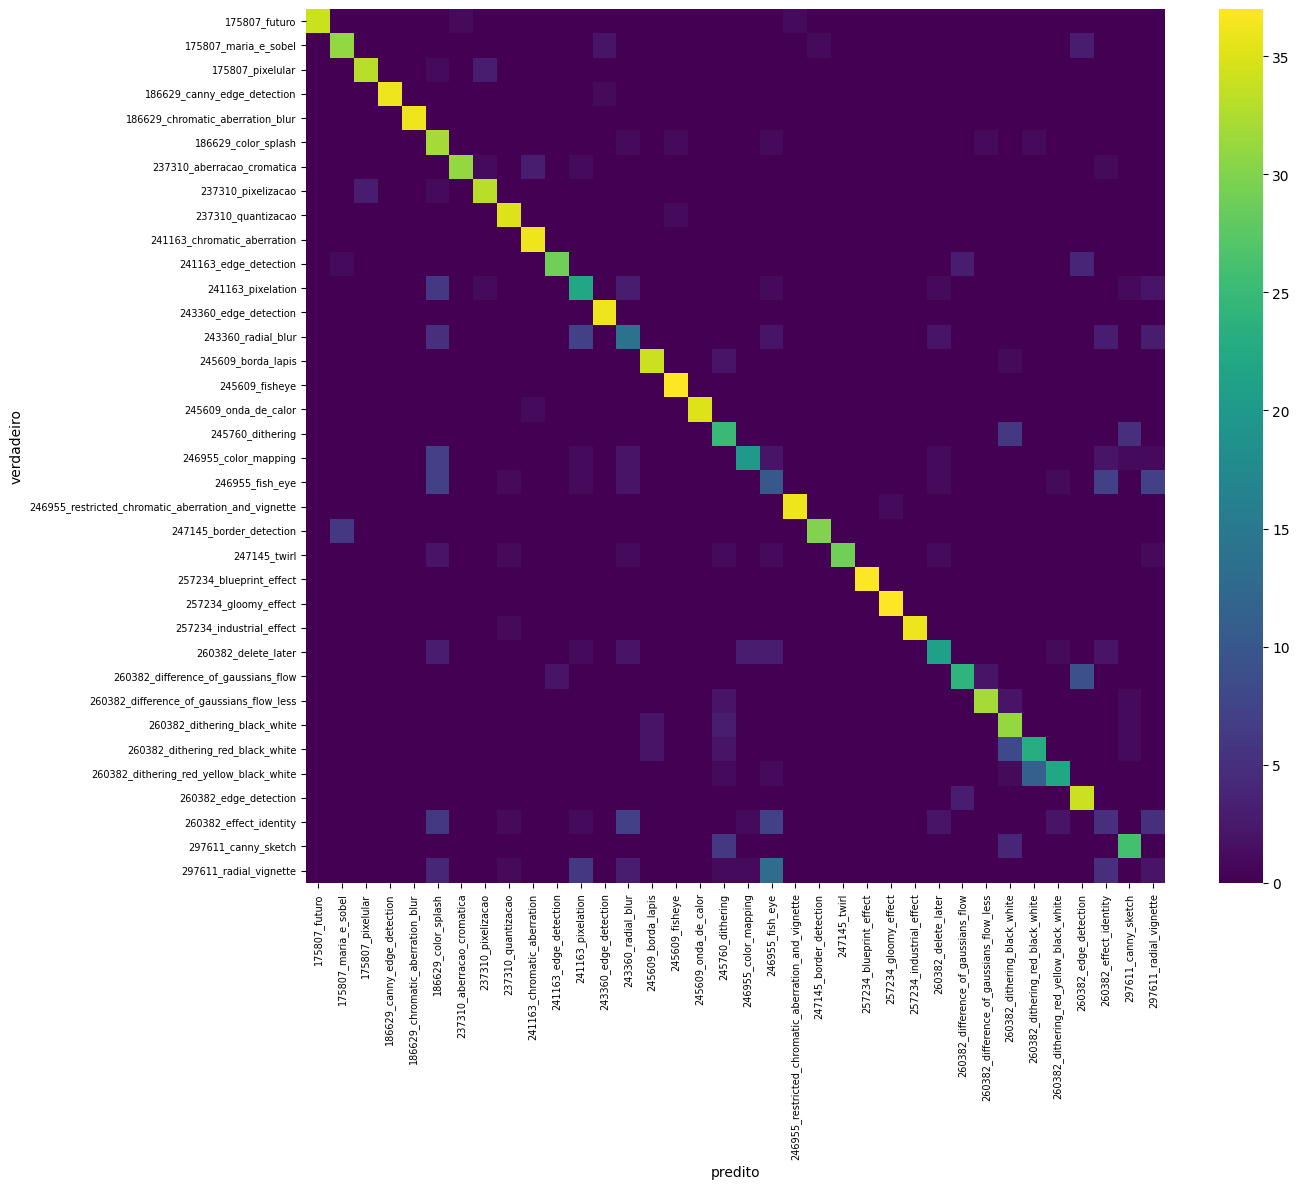

In [57]:
import seaborn as sns

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

def supervised_metrics(y_true, y_pred_mapped):
    return {
        "accuracy":    accuracy_score(y_true, y_pred_mapped),
        "precision":   precision_score(y_true, y_pred_mapped,
                                       average="macro", zero_division=0),
        "recall":      recall_score(y_true, y_pred_mapped,
                                    average="macro", zero_division=0),
        "f1_macro":    f1_score(y_true, y_pred_mapped,
                                average="macro", zero_division=0),
    }

y_pred = grid.predict(X_te)

# Recupera os nomes das classes originais e das classes preditas
y_te_names = label_encoder.inverse_transform(y_te)
y_pred_names = label_encoder.inverse_transform(y_pred)

print(supervised_metrics(y_te_names, y_pred_names))
print(classification_report(y_te_names, y_pred_names, zero_division=0))

# matriz de confusão
classes = class_names
cm = confusion_matrix(y_te_names, y_pred_names, labels=classes)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, xticklabels=classes, yticklabels=classes,
            cmap="viridis", ax=ax)
ax.set_xlabel("predito"); ax.set_ylabel("verdadeiro")
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()